In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [ ]:
# Load Dataset
df = pd.read_csv('/content/ecommerce.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,554697,21166,COOK WITH WINE METAL SIGN,1,5/25/2011 17:31,2.08,14584,United Kingdom
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,7/24/2011 11:58,2.55,17114,United Kingdom
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,7/19/2011 12:54,1.65,15311,United Kingdom
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,7/13/2011 11:34,1.25,16843,United Kingdom
4,544450,21789,KIDS RAIN MAC PINK,3,2/20/2011 12:23,0.85,17811,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    4870 non-null   int64  
 1   StockCode    4870 non-null   object 
 2   Description  4870 non-null   object 
 3   Quantity     4870 non-null   int64  
 4   InvoiceDate  4870 non-null   object 
 5   UnitPrice    4870 non-null   float64
 6   CustomerID   4870 non-null   int64  
 7   Country      4870 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 304.5+ KB


In [ ]:
df.describe()

,InvoiceNo,Quantity,UnitPrice,CustomerID
count,4870.000000,4870.000000,4870.000000,4870.000000
mean,560586.577413,12.945791,2.937057,15291.004312
std,13211.347819,38.145988,4.744515,1709.035002
min,536365.000000,1.000000,0.040000,12347.000000
25%,548861.000000,2.000000,1.250000,13975.000000
50%,561895.000000,5.000000,1.950000,15144.000000
75%,572126.000000,12.000000,3.750000,16793.250000
max,581585.000000,992.000000,145.000000,18283.000000


In [ ]:
# Cek Duplikasi
df.duplicated().sum()

np.int64(0)

In [ ]:
# Cek duplikat pada kolom InvoiceNo
df['InvoiceNo'].duplicated().sum()

np.int64(1066)

In [ ]:
# Mengambil contoh InvoiceNo yang muncul lebih dari sekali
df_check = df.groupby('InvoiceNo').agg(
    total_muncul = ('InvoiceNo', 'count')
)
# Urutkan berdasarkan total kemunculan secara menurun
df_check = df_check.sort_values('total_muncul',ascending=False)

df_check.head()

,total_muncul
InvoiceNo,
562046,8
578270,7
575491,7
576339,7
559552,6


In [ ]:
# Kita periksa untuk salah satu InvoiceNo yang muncul.
df[df['InvoiceNo'] == 575491]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1116,575491,23534,WALL ART STOP FOR TEA,3,11/9/2011 17:47,5.95,15531,United Kingdom
2628,575491,22726,ALARM CLOCK BAKELIKE GREEN,1,11/9/2011 17:47,3.75,15531,United Kingdom
3176,575491,22865,HAND WARMER OWL DESIGN,2,11/9/2011 17:47,2.10,15531,United Kingdom
3810,575491,23558,LANDMARK FRAME LONDON BRIDGE,1,11/9/2011 17:47,12.50,15531,United Kingdom
4251,575491,22727,ALARM CLOCK BAKELIKE RED,1,11/9/2011 17:47,3.75,15531,United Kingdom
4409,575491,21164,HOME SWEET HOME METAL SIGN,1,11/9/2011 17:47,2.95,15531,United Kingdom
4497,575491,21166,COOK WITH WINE METAL SIGN,2,11/9/2011 17:47,2.08,15531,United Kingdom


In [ ]:
# Ternyata InvoiceNo tersebut muncul hingga 7 kali
# disebabkan terdapat 7 StockCode yang berbeda dalam satu invoice


In [ ]:
df[['InvoiceNo', 'StockCode']].duplicated().sum()

np.int64(1)

In [ ]:
# Untuk setiap InvoiceNo dan StockCode, dihitung berapa kali muncul dalam dataset
df_check = df.groupby(['InvoiceNo', 'StockCode']).agg(
    total = ('InvoiceNo', 'count')
)

df_check = df_check.sort_values('total', ascending=False)

df_check.head()

total
InvoiceNo StockCode       
574714    21817          2
569122    22423          1
569110    20728          1
569089    23319          1
          21430          1

In [ ]:
# cek untuk InvoceNo dan StockCode yang masih duplikat
conditions = (
    (df['InvoiceNo'] == 574714)
    & (df['StockCode'] == '21817')
)

df[conditions]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2830,574714,21817,GLITTER CHRISTMAS TREE,1,11/6/2011 14:29,0.39,15427,United Kingdom
3758,574714,21817,GLITTER CHRISTMAS TREE,5,11/6/2011 14:29,0.39,15427,United Kingdom


In [ ]:
# Karena pada kedua data memiliki
# Maka data duplikat akan dijumlahkan dengan identifikasi uniknya
df = df.groupby(['InvoiceNo', 'StockCode']).agg({
    'Description': 'min',
    'InvoiceDate': 'min',
    'UnitPrice': 'min',
    'CustomerID': 'min',
    'Country': 'min',
    'Quantity': 'sum'
})

df = df.reset_index()
df.shape

(4869, 8)

In [ ]:
# Cek kembali apakah sudah berhasil dijumlahkan?
conditions = (
    (df['InvoiceNo'] == 574714)
    & (df['StockCode'] == '21817')
)

df[conditions]

,InvoiceNo,StockCode,Description,InvoiceDate,UnitPrice,CustomerID,Country,Quantity
3970,574714,21817,GLITTER CHRISTMAS TREE,11/6/2011 14:29,0.39,15427,United Kingdom,6


## Check Missing Values

In [ ]:
# Cek Missing Value
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
Quantity,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4869 entries, 0 to 4868
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    4869 non-null   int64  
 1   StockCode    4869 non-null   object 
 2   Description  4869 non-null   object 
 3   InvoiceDate  4869 non-null   object 
 4   UnitPrice    4869 non-null   float64
 5   CustomerID   4869 non-null   int64  
 6   Country      4869 non-null   object 
 7   Quantity     4869 non-null   int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 304.4+ KB


In [ ]:
# Menangani tipe data date secara khusus.
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Karena nomor invoce (InvoiceNo) dan CustomerID itu bukanlah sebuah variabel numerik
# dan tidak perlu adanya operasi matematika
# maka kita ubah tipe datanya menjadi string (object)
df['InvoiceNo'] = df['InvoiceNo'].astype('string')
df['CustomerID'] = df['CustomerID'].astype('string')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4869 entries, 0 to 4868
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    4869 non-null   string        
 1   StockCode    4869 non-null   object        
 2   Description  4869 non-null   object        
 3   InvoiceDate  4869 non-null   datetime64[ns]
 4   UnitPrice    4869 non-null   float64       
 5   CustomerID   4869 non-null   string        
 6   Country      4869 non-null   object        
 7   Quantity     4869 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(3), string(2)
memory usage: 304.4+ KB


In [ ]:
# Mengecek statistik dasar tipe data kategori. Berdasarkan keluarannya, kolom
# mana saja yang masuk akal untuk dicek nilainya satu-satu?
df.select_dtypes(include=['object', 'string']).describe()

,InvoiceNo,StockCode,Description,CustomerID,Country
count,4869,4869,4869,4869,4869
unique,3804,1773,1807,1932,31
top,562046,85099B,JUMBO BAG RED RETROSPOT,17841,United Kingdom
freq,8,24,24,112,4345


In [ ]:
df['Country'].value_counts()

,count
Country,
United Kingdom,4345
Germany,121
EIRE,90
France,89
Switzerland,28
Netherlands,26
Spain,25
Belgium,21
Portugal,16


In [ ]:
df.select_dtypes(include='number').describe()

,UnitPrice,Quantity
count,4869.000000,4869.000000
mean,2.937581,12.948449
std,4.744862,38.149481
min,0.040000,1.000000
25%,1.250000,2.000000
50%,1.950000,5.000000
75%,3.750000,12.000000
max,145.000000,992.000000


In [ ]:
df.select_dtypes(include='datetime').describe()

,InvoiceDate
count,4869
mean,2011-07-10 12:15:19.112754176
min,2010-12-01 08:26:00
25%,2011-04-04 13:38:00
50%,2011-07-31 15:00:00
75%,2011-10-21 08:40:00
max,2011-12-09 12:31:00


Berdasarkan hasil eksplorasi secara statistik tidak terdapat missing value baik itu nilai NaN maupun data yang tidak sesuai.

## Check Outliers

Pengecekan outliers akan hanya dilakukan pada kolome bertipe data numerik

In [ ]:
def show_distribution(data: pd.Series):
  fig, axes = plt.subplots(nrows=1, ncols=3)

  fig.set_size_inches(12, 4)

  sm.qqplot(data, line ='r', ax=axes[0])
  axes[0].set_title('Q-Q Plot')

  data.plot.box(ax=axes[1])
  axes[1].set_title('Box Plot')

  data.plot.hist(ax=axes[2])
  axes[2].set_title('Histogram')

  plt.tight_layout()
  plt.show()

### Unit Price

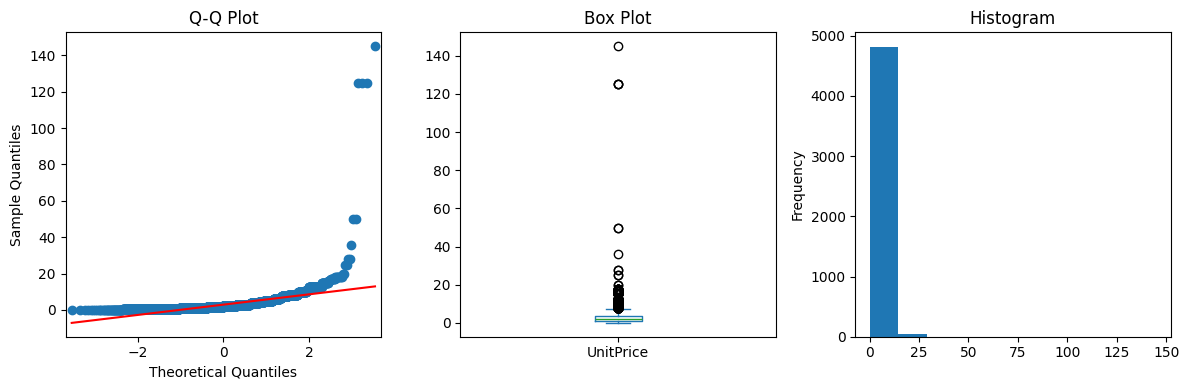

In [ ]:
show_distribution(df['UnitPrice'])

In [ ]:
conditions = (df['UnitPrice'] > 40)
df[conditions]

,InvoiceNo,StockCode,Description,InvoiceDate,UnitPrice,CustomerID,Country,Quantity
447,541282,22655,VINTAGE RED KITCHEN CABINET,2011-01-17 12:31:00,125.0,17690,United Kingdom,2
815,544934,C2,CARRIAGE,2011-02-25 09:01:00,50.0,13345,United Kingdom,1
840,545158,22655,VINTAGE RED KITCHEN CABINET,2011-02-28 13:28:00,125.0,15874,United Kingdom,1
889,545543,22656,VINTAGE BLUE KITCHEN CABINET,2011-03-03 14:43:00,125.0,13476,United Kingdom,1
1713,554084,22827,RUSTIC SEVENTEEN DRAWER SIDEBOARD,2011-05-22 11:52:00,145.0,12909,United Kingdom,2
2655,563911,C2,CARRIAGE,2011-08-21 12:39:00,50.0,16265,United Kingdom,1


In [ ]:
conditions = (df['UnitPrice'] <= 0)
df[conditions]

,InvoiceNo,StockCode,Description,InvoiceDate,UnitPrice,CustomerID,Country,Quantity


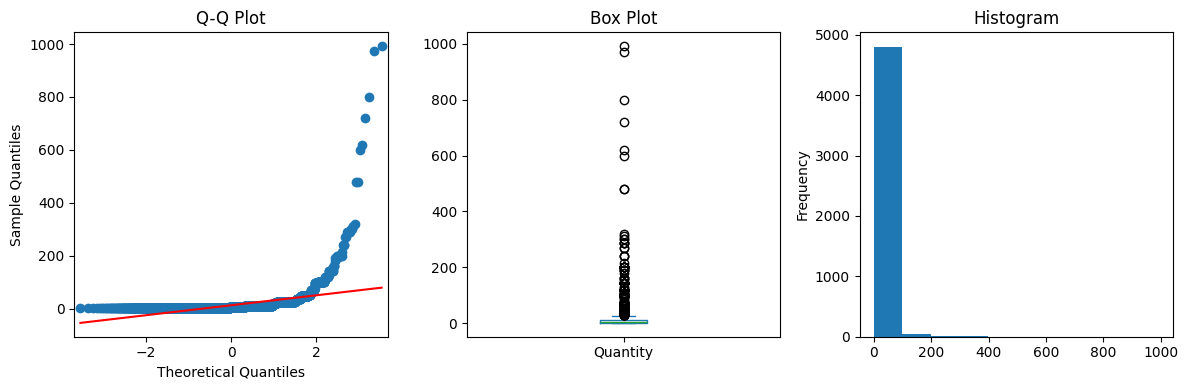

In [ ]:
show_distribution(df['Quantity'])

In [ ]:
conditions = (df['Quantity'] > 400)
df[conditions]

,InvoiceNo,StockCode,Description,InvoiceDate,UnitPrice,CustomerID,Country,Quantity
135,537657,22189,CREAM HEART CARD HOLDER,2010-12-07 16:42:00,2.31,18102,United Kingdom,972
278,539257,21137,BLACK RECORD COVER FRAME,2010-12-16 14:29:00,3.39,16210,United Kingdom,480
608,543099,22985,"WRAP, BILLBOARD FONTS DESIGN",2011-02-03 12:00:00,0.34,16684,United Kingdom,800
982,546530,21977,PACK OF 60 PINK PAISLEY CAKE CASES,2011-03-14 13:25:00,0.55,17404,Sweden,480
1430,551062,15036,ASSORTED COLOURS SILK FAN,2011-04-26 12:16:00,0.72,18092,United Kingdom,600
3684,572340,22102,MIRROR MOSAIC T-LIGHT HOLDER,2011-10-24 10:36:00,0.39,14607,United Kingdom,720
3902,574293,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2011-11-03 15:32:00,3.20,17450,United Kingdom,992
4813,581107,23461,SWEETHEART BIRD HOUSE,2011-12-07 12:15:00,3.30,16000,United Kingdom,620


In [ ]:
conditions = (df['Quantity'] <= 0)
df[conditions]

,InvoiceNo,StockCode,Description,InvoiceDate,UnitPrice,CustomerID,Country,Quantity


## EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4869 entries, 0 to 4868
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    4869 non-null   string        
 1   StockCode    4869 non-null   object        
 2   Description  4869 non-null   object        
 3   InvoiceDate  4869 non-null   datetime64[ns]
 4   UnitPrice    4869 non-null   float64       
 5   CustomerID   4869 non-null   string        
 6   Country      4869 non-null   object        
 7   Quantity     4869 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(3), string(2)
memory usage: 304.4+ KB


### Feature Construction

In [ ]:
# Buat kolom Total Price (revenue)
df['TotalPrice'] = df['UnitPrice'] * df['Quantity']
df[['UnitPrice', 'Quantity', 'TotalPrice']].sample(3)

,UnitPrice,Quantity,TotalPrice
4661,2.10,2,4.20
3119,1.45,12,17.40
3007,2.08,1,2.08


In [ ]:
# Buat kolom InvoiceDate dalam bulan
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df[['InvoiceDate', 'InvoiceMonth']].sample(3)

,InvoiceDate,InvoiceMonth
2726,2011-08-25 18:45:00,2011-08
2404,2011-07-28 12:28:00,2011-07
4840,2011-12-08 12:26:00,2011-12


## Pertanyaan analisis

### 1. Bagaimana distribusi nilai transaksi per invoice?

In [ ]:
# melakukan aggregasi untuk melihat nilai transaksi per invoice
df_invoice = (
    df.groupby('InvoiceNo').agg(
        TotalQuantity = ('Quantity', 'sum'),
        TotalRevenue = ('TotalPrice', 'sum'),
    ).sort_values('TotalRevenue', ascending=False)
)
df_invoice.head()

,TotalQuantity,TotalRevenue
InvoiceNo,,
574293,992,3174.40
537657,972,2245.32
581107,620,2046.00
564312,612,1863.00
539257,480,1627.20


In [ ]:
df_invoice.describe()

,TotalQuantity,TotalRevenue
count,3804.000000,3804.000000
mean,16.573607,29.384834
std,45.350594,96.911005
min,1.000000,0.190000
25%,3.000000,6.742500
50%,6.000000,15.000000
75%,14.000000,25.000000
max,992.000000,3174.400000


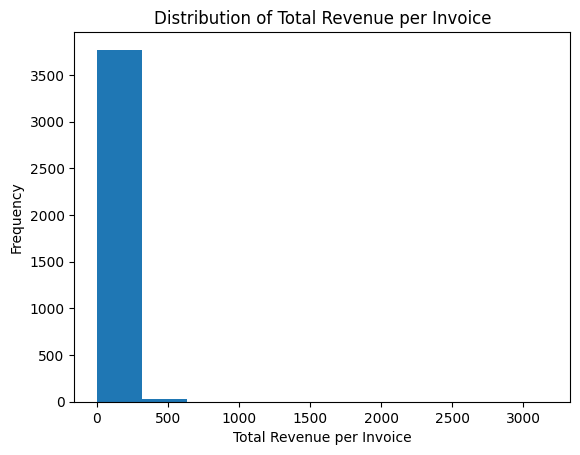

In [ ]:
# Plot Distribusi Total Revenue per Invoice
plt.figure()
plt.hist(df_invoice["TotalRevenue"], bins=10)
plt.xlabel("Total Revenue per Invoice")
plt.ylabel("Frequency")
plt.title("Distribution of Total Revenue per Invoice")
plt.show()

Berdasarkan Grafik distribusi nilai transaksi per invoice terlihat bahwa sebagian besar transaksi bernilai relatif kecil, namun terdapat beberapa invoice dengan nilai transaksi yang sangat besar.

### 1a. Berdasarkan distribusi tersebut, apakah nilai transaksi per invoice nya itu cendrung meningkat sejalan dengan bertambahnya jumlah barang yang dibeli?

<Axes: xlabel='TotalQuantity', ylabel='TotalRevenue'>

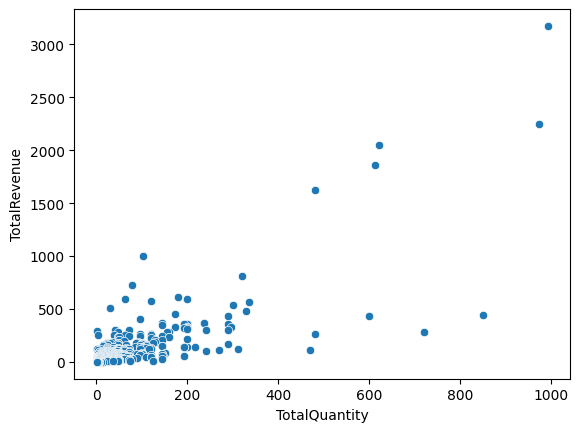

In [ ]:
# Scatter plot untuk melihat hubungan antara jumlah barang dan total revenue
plt.figure()
sns.scatterplot(
    data=df_invoice,
    x='TotalQuantity',
    y='TotalRevenue'
)

In [ ]:
# Melihat korelasi antar variabel TotalQuantity dengan TotalRevenue
df_invoice[['TotalQuantity','TotalRevenue']].corr()

,TotalQuantity,TotalRevenue
TotalQuantity,1.00000,0.79637
TotalRevenue,0.79637,1.00000


Terlihat bahwa terdapat hubungan positif yang cukup kuat antara jumlah barang dengan nilai transaksi (revenue) per invoice. Invoice dengan jumlah barang yang lebih banyak cendrung memiliki nilai transaksi yang lebih tinggi, sehingga semakin banyak barang yang dibeli per invoice semakin meningkat juga nilai transaksi per invoicenya.

### 2. Bagaimana perbandingan nilai transaksi (Revenue) berdasarkan country?

In [ ]:
# melakukan aggregasi untuk melihat nilai transaksi berdasarkan negara
df_country_rev = df.groupby('Country').agg(
    TotalRevenue = ('TotalPrice', 'sum')
).sort_values('TotalRevenue', ascending=False)

df_country_rev.head(10)

,TotalRevenue
Country,
United Kingdom,93011.36
Netherlands,3622.33
Germany,3363.77
EIRE,3156.78
France,2320.55
Sweden,988.74
Australia,937.00
Switzerland,902.52
Portugal,562.90


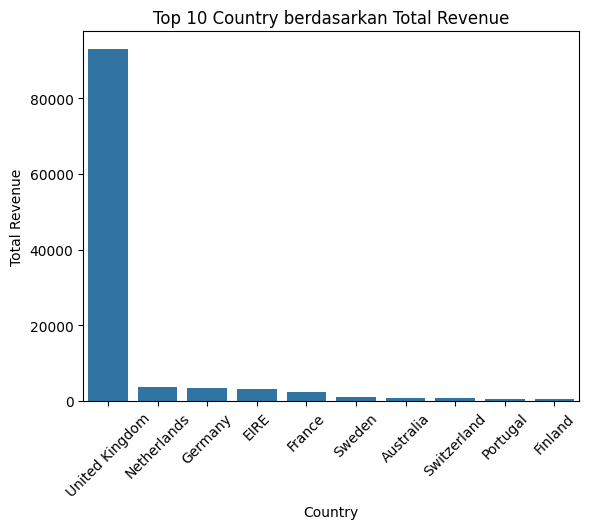

In [ ]:
# Plot untuk melihat Top 10 Country berdasarkan Total Revenue
top10_country = df_country_rev.head(10)

plt.figure()
sns.barplot(
    top10_country,
    x='Country',
    y='TotalRevenue'
)
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.title("Top 10 Country berdasarkan Total Revenue")
plt.xticks(rotation=45)
plt.show()

### 2a. Seberapa besar kontribusi negara United Kingdom tehadap keseluruhan revenue?

In [ ]:
# Hitung total revenue keseluruhan
total_rev = df_country_rev['TotalRevenue'].sum()

# Hitung persentase tiap Countrynya
df_country_rev['RevenuePercentage'] = (
    df_country_rev['TotalRevenue'] / total_rev * 100
)
df_country_rev.head()

,TotalRevenue,RevenuePercentage
Country,,
United Kingdom,93011.36,83.209371
Netherlands,3622.33,3.240591
Germany,3363.77,3.009280
EIRE,3156.78,2.824103
France,2320.55,2.075999


Terlihat bahwa United Kingdom menjadi penyumbang terbesar Total Revenue dibandingkan negara lainnya. Kontribusinya mencapai sekitar 83% yang mana ini jauh mendominasi, sementara negara lain hanya menyumbang sebagian kecil dari Total Revenue

### 3. Bagaimana pola nilai transaksi (Revenue) per invoice berdasarkan bulan?

In [ ]:
# Membuat aggregasi untuk melihat nilai transaksi per invoice berdasarkan bulan
df_monthly_rev = df.groupby('InvoiceMonth').agg(
    TotalRevenue = ('TotalPrice','sum')
).sort_values('TotalRevenue', ascending=False)

df_monthly_rev.reset_index(inplace=True)
df_monthly_rev

,InvoiceMonth,TotalRevenue
0,2011-11,17948.84
1,2010-12,10810.55
2,2011-10,10177.38
3,2011-08,9904.91
4,2011-09,9761.11
5,2011-07,7569.27
6,2011-06,7203.93
7,2011-03,7162.64
8,2011-05,6987.24
9,2011-04,6357.63


In [ ]:
# ubah dari period menjadi timestamp
df_monthly_rev['InvoiceMonth'] = df_monthly_rev['InvoiceMonth'].dt.to_timestamp()

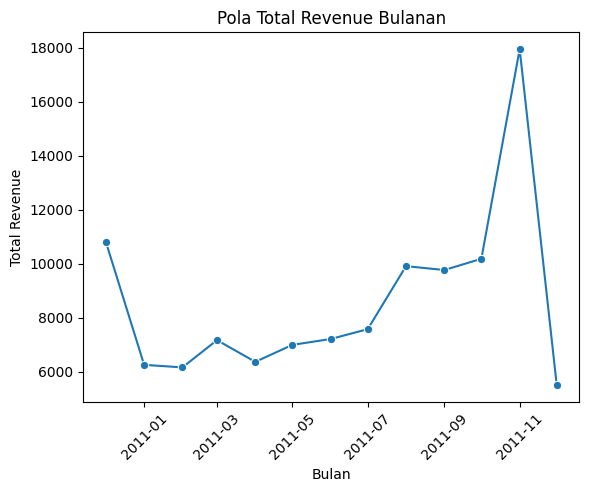

In [ ]:
# Menampilkan tren Total Revenue dari bulan ke bulan
plt.figure()
sns.lineplot(
    data=df_monthly_rev,
    x='InvoiceMonth',
    y='TotalRevenue',
    marker='o'
)
plt.xlabel("Bulan")
plt.ylabel("Total Revenue")
plt.title("Pola Total Revenue Bulanan")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# cek data bulan des 2010

df_dec_2010 = df[
    df['InvoiceDate'].dt.to_period('M') == '2010-12'
]
df_dec_2010

,InvoiceNo,StockCode,Description,InvoiceDate,UnitPrice,CustomerID,Country,Quantity,TotalPrice,InvoiceMonth
0,536365,84406B,CREAM CUPID HEARTS COAT HANGER,2010-12-01 08:26:00,2.75,17850,United Kingdom,8,22.00,2010-12
1,536381,22438,BALLOON ART MAKE YOUR OWN FLOWERS,2010-12-01 09:41:00,1.95,15311,United Kingdom,1,1.95,2010-12
2,536394,22866,HAND WARMER SCOTTY DOG DESIGN,2010-12-01 10:39:00,1.85,13408,United Kingdom,96,177.60,2010-12
3,536397,35004B,SET OF 3 BLACK FLYING DUCKS,2010-12-01 10:51:00,4.65,17924,United Kingdom,12,55.80,2010-12
4,536404,22417,PACK OF 60 SPACEBOY CAKE CASES,2010-12-01 11:29:00,0.55,16218,United Kingdom,24,13.20,2010-12
...,...,...,...,...,...,...,...,...,...,...
316,539766,22960,JAM MAKING SET WITH JARS,2010-12-22 11:11:00,4.25,14092,United Kingdom,6,25.50,2010-12
317,539829,82613D,METAL SIGN CUPCAKE SINGLE HOOK,2010-12-22 12:47:00,0.42,12734,France,20,8.40,2010-12
318,539831,85049G,CHOCOLATE BOX RIBBONS,2010-12-22 13:17:00,1.25,14606,United Kingdom,1,1.25,2010-12
319,539953,85018D,YULETIDE IMAGES S/6 PAPER BOXES,2010-12-23 12:03:00,2.55,12748,United Kingdom,1,2.55,2010-12


In [ ]:
# Cek data bulan des 2011

df_dec_2011 = df[
    df['InvoiceDate'].dt.to_period('M') == '2011-12'
]
df_dec_2011

,InvoiceNo,StockCode,Description,InvoiceDate,UnitPrice,CustomerID,Country,Quantity,TotalPrice,InvoiceMonth
4658,579938,84378,SET OF 3 HEART COOKIE CUTTERS,2011-12-01 10:18:00,1.45,14146,United Kingdom,12,17.40,2011-12
4659,579940,22086,PAPER CHAIN KIT 50'S CHRISTMAS,2011-12-01 10:20:00,2.95,16938,United Kingdom,6,17.70,2011-12
4660,579949,22998,TRAVEL CARD WALLET KEEP CALM,2011-12-01 11:00:00,0.42,16700,United Kingdom,48,20.16,2011-12
4661,579980,85152,HAND OVER THE CHOCOLATE SIGN,2011-12-01 11:16:00,2.10,13263,United Kingdom,2,4.20,2011-12
4662,579986,84029E,RED WOOLLY HOTTIE WHITE HEART.,2011-12-01 11:18:00,3.39,13777,United Kingdom,180,610.20,2011-12
...,...,...,...,...,...,...,...,...,...,...
4864,581478,22791,T-LIGHT GLASS FLUTED ANTIQUE,2011-12-09 08:59:00,1.25,17364,United Kingdom,12,15.00,2011-12
4865,581481,22721,SET OF 3 CAKE TINS SKETCHBOOK,2011-12-09 09:07:00,1.95,17490,United Kingdom,12,23.40,2011-12
4866,581538,22899,CHILDREN'S APRON DOLLY GIRL,2011-12-09 11:34:00,2.10,14446,United Kingdom,2,4.20,2011-12
4867,581538,23525,WALL ART BUFFALO BILL,2011-12-09 11:34:00,3.75,14446,United Kingdom,1,3.75,2011-12


Berdasarkan visualisasi total revenue bulanan, terlihat bahwa bulan desember 2010 memiliki total revenue yang relatif tinggi, diikuti dengan penurunan yang cukup tajam pada januari 2011. Setelah periode tersebut total revenue bergerak fluktuatif dengan menunjukkan kecendrungan meningkat hingga mencapai puncaknya pada bulan november 2011 dan menurun kembali pada desember 2011. Namun penurunan yang terjadi pada bulan desember 2011 ini perlu diiterpretasikan dengan hati hati karena datanya belum mencakup keseluruhan periodenya (hanya sampai tanggal 9 desember 2011).

### 3a. Apakah penurunan total revenue dari bulan Desember 2010 ke januari 2011 dipengaruhi oleh penurunan jumlah transaksi atau penurunan nilai transaki per invoice?

In [ ]:
# Filter data hanya pada bulan desember 2010 dan januari 2011
df_temp = df[
    (df['InvoiceDate'] >= '2010-12-01') &
    (df['InvoiceDate'] <  '2011-02-01')
]
df_temp.head()

,InvoiceNo,StockCode,Description,InvoiceDate,UnitPrice,CustomerID,Country,Quantity,TotalPrice,InvoiceMonth
0,536365,84406B,CREAM CUPID HEARTS COAT HANGER,2010-12-01 08:26:00,2.75,17850,United Kingdom,8,22.00,2010-12
1,536381,22438,BALLOON ART MAKE YOUR OWN FLOWERS,2010-12-01 09:41:00,1.95,15311,United Kingdom,1,1.95,2010-12
2,536394,22866,HAND WARMER SCOTTY DOG DESIGN,2010-12-01 10:39:00,1.85,13408,United Kingdom,96,177.60,2010-12
3,536397,35004B,SET OF 3 BLACK FLYING DUCKS,2010-12-01 10:51:00,4.65,17924,United Kingdom,12,55.80,2010-12
4,536404,22417,PACK OF 60 SPACEBOY CAKE CASES,2010-12-01 11:29:00,0.55,16218,United Kingdom,24,13.20,2010-12


In [ ]:
# membuat aggregasi
df_check = df_temp.groupby(df_temp['InvoiceDate'].dt.to_period('M')).agg(
    TotalRevenue=('TotalPrice', 'sum'),
    InvoiceCount=('InvoiceNo', 'nunique')
)
df_check['AvgRevenuePerInvoice'] = (
    df_check['TotalRevenue'] / df_check['InvoiceCount']
)
df_check

,TotalRevenue,InvoiceCount,AvgRevenuePerInvoice
InvoiceDate,,,
2010-12,10810.55,264,40.949053
2011-01,6247.52,219,28.527489


Berdasarkan perbandingan, terlihat bahwa penurutan total revenue diikuti oleh penurunan jumlah invoicenya (transaksinya). Perbedaan dalam pola penurunan ini mengindikasikan bahwa transaksi rata rata per invoice berkontribusi terhadap penurunan total revenue.

### 4. Bagaimana kontribusi revenue berdasarkan customer, dan siapa saja customer dengan kontribusi tertinggi terhadap total penjualan?

In [ ]:
# membuat aggregasi untuk melihat top 10 customer dengan kontribusi yang tinggi
# pada revenue
top10_cust = (
    df.groupby('CustomerID')
    .agg(TotalRevenue = ('TotalPrice', 'sum'))
    .sort_values('TotalRevenue', ascending=False)
    .head(10)
)
top10_cust.reset_index(inplace=True)
top10_cust

,CustomerID,TotalRevenue
0,14646,3569.53
1,17450,3521.44
2,15769,3509.00
3,18102,2940.42
4,14911,2149.65
5,16000,2046.00
6,14088,1900.38
7,16210,1728.00
8,16029,1472.40
9,17511,1334.64


Berdasarkan analisis terlihat bahwa terdapat sejumlah customer dengan kontribusi revenue yang lebih tinggi. Kontribusi pada tiga customer teratas relatif berimbang, sementara setelahnya kontribusi mulai menurun, tanpa adanya dominasi dari satu customer.

### 4a. Produk apa saja yang paling sering dibeli oleh top customer ini?

In [ ]:
df_top_cust = df[df["CustomerID"].isin(top10_cust["CustomerID"])]
df_top_cust

,InvoiceNo,StockCode,Description,InvoiceDate,UnitPrice,CustomerID,Country,Quantity,TotalPrice,InvoiceMonth
16,536540,21055,TOOL BOX SOFT TOY,2010-12-01 14:05:00,8.95,14911,EIRE,4,35.80,2010-12
53,536975,22704,WRAP RED APPLES,2010-12-03 14:04:00,0.42,14911,EIRE,25,10.50,2010-12
135,537657,22189,CREAM HEART CARD HOLDER,2010-12-07 16:42:00,2.31,18102,United Kingdom,972,2245.32,2010-12
193,538255,21181,PLEASE ONE PERSON METAL SIGN,2010-12-10 12:33:00,2.10,14911,EIRE,12,25.20,2010-12
194,538255,22794,SWEETHEART WIRE MAGAZINE RACK,2010-12-10 12:33:00,7.95,14911,EIRE,2,15.90,2010-12
...,...,...,...,...,...,...,...,...,...,...
4808,581006,23343,JUMBO BAG VINTAGE CHRISTMAS,2011-12-07 08:45:00,2.08,14911,EIRE,10,20.80,2011-12
4811,581098,23029,DRAWER KNOB CRACKLE GLAZE GREEN,2011-12-07 11:42:00,1.65,14911,EIRE,12,19.80,2011-12
4812,581098,23479,WIRE EGG BASKET,2011-12-07 11:42:00,7.85,14911,EIRE,2,15.70,2011-12
4813,581107,23461,SWEETHEART BIRD HOUSE,2011-12-07 12:15:00,3.30,16000,United Kingdom,620,2046.00,2011-12


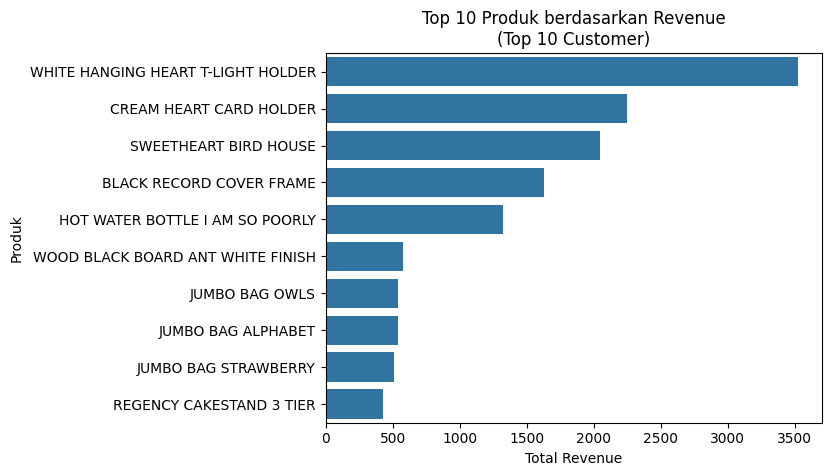

In [ ]:
top_prod_rev = df_top_cust.groupby('Description').agg(
    TotalRevenue=('TotalPrice', 'sum')
).sort_values('TotalRevenue', ascending=False).reset_index()

plt.figure()
sns.barplot(
    data=top_prod_rev.head(10),
    x='TotalRevenue',
    y='Description'
)
plt.title("Top 10 Produk berdasarkan Revenue\n(Top 10 Customer)")
plt.xlabel("Total Revenue")
plt.ylabel("Produk")
plt.show()

Berdasarkan plot terlihat bahwa customer dengan total belanja tertinggi cenderung berfokus pada beberapa produk tertentu yang berkontribusi besar terhadap revenue. Produk-produk ini berpotensi menjadi penggerak utama pendapatan, sehingga optimalisasi ketersediaan dan strategi promosi dapat meningkatkan efisiensi dan keberlanjutan revenue perusahaan.

### 5. Apakah total revenue lebih dipengaruhi oleh harga produk atau oleh jumlah unit yang terjual?


In [ ]:
# Membuat aggregasi
df_prod = df.groupby('Description').agg(
    AvgUnitPrice=("UnitPrice", "mean"),
    TotalQuantity=("Quantity", "sum"),
    TotalRevenue=("TotalPrice", "sum")
)
df_prod.head()

,AvgUnitPrice,TotalQuantity,TotalRevenue
Description,,,
50'S CHRISTMAS GIFT BAG LARGE,1.25,24,30.00
DOLLY GIRL BEAKER,1.25,51,63.75
I LOVE LONDON MINI BACKPACK,4.15,8,33.20
RED SPOT GIFT BAG LARGE,1.25,12,15.00
SET 2 TEA TOWELS I LOVE LONDON,3.10,6,18.00


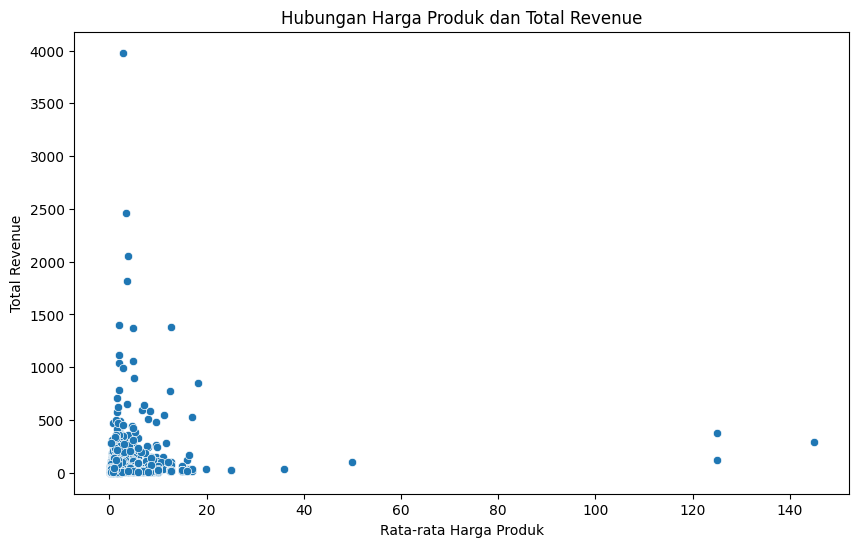

In [ ]:
# Plot untuk melihat hubungan antara harga produk dan revenue
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_prod,
    x="AvgUnitPrice",
    y="TotalRevenue",
)

plt.title("Hubungan Harga Produk dan Total Revenue")
plt.xlabel("Rata-rata Harga Produk")
plt.ylabel("Total Revenue")
plt.show()

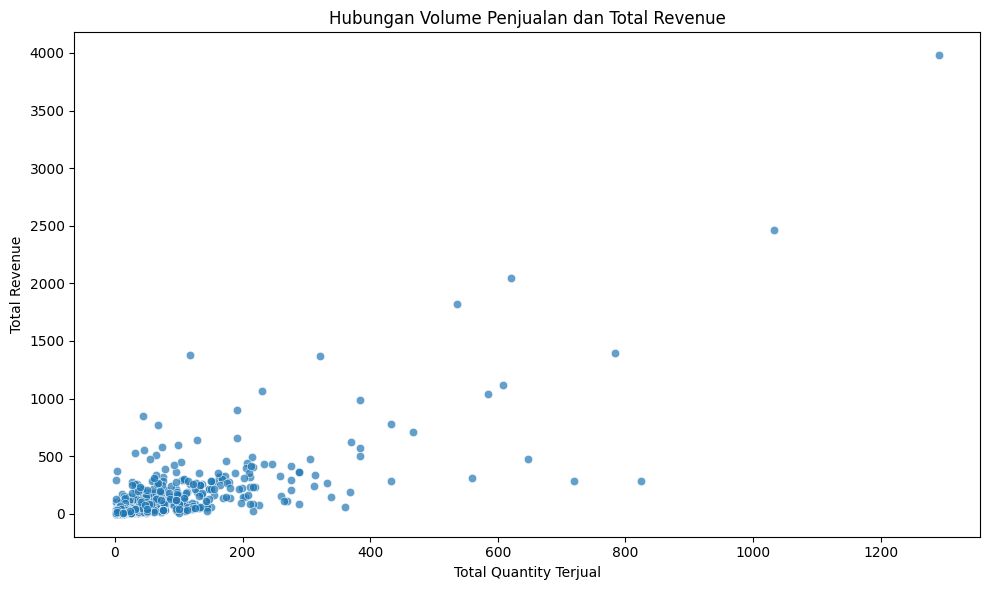

In [ ]:
# Plot untuk melihat hubungan antara volume penjualan dan revenue
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_prod,
    x="TotalQuantity",
    y="TotalRevenue",
    alpha=0.7
)

plt.title("Hubungan Volume Penjualan dan Total Revenue")
plt.xlabel("Total Quantity Terjual")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

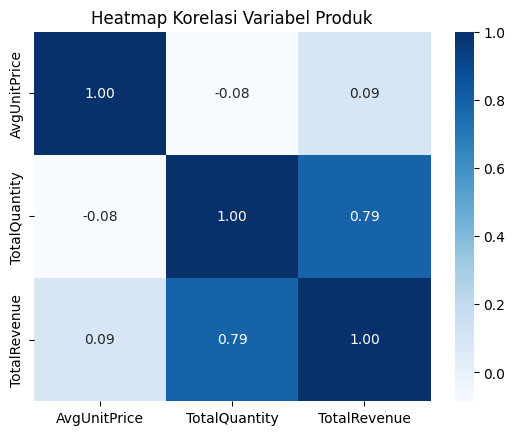

In [ ]:
# Membuat heatmap untuk cek korelasi
corr_matrix = df_prod[
    ["AvgUnitPrice", "TotalQuantity", "TotalRevenue"]
].corr()

plt.figure()
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Heatmap Korelasi Variabel Produk")
plt.show()

Berdasarkan hasil visualisasi terlihat bahwa harga produk tidak menunjukkan hubungan yang kuat dengan total revenue.
Produk dengan harga tinggi tidak secara konsisten menghasilkan revenue yang besar.
Sebaliknya, hubungan antara volume penjualan dan total revenue terlihat lebih jelas dan positif.
Hal ini menunjukkan bahwa revenue perusahaan lebih banyak didorong oleh tingginya volume penjualan dibandingkan harga produk.